# <h1 style='color: #1B3A6B;'> 1. NOMBRE DEL PROYECTO </H1>

## <span style='color: #2E86AB;'> PREDICCIÓN DE ABANDONO DE CLIENTES - BETA BANK (CHURN) </span>

---
# <span style='color: #1B3A6B;'> 2. OBJETIVO </span>
---
## <span style='color: #2E86AB;'> 2.1 General </span>

* Desarrollar un modelo de clasificación binaria que prediga si un cliente de Beta Bank abandonará el banco próximamente (**Exited = 1**) o no (**Exited = 0**), con base a su comportamiento e historial con el banco.

## <span style='color: #2E86AB;'> 2.2 Específico </span>

* Identificar un criterio mínimo de aprobación F1 Score ≥ 0.59 en el conjunto de prueba.
* Evaluar la métrica secundaria AUC-ROC y comparar con el valor F1.

---
# <span style='color: #1B3A6B;'> 3. DESCRIPCIÓN </span>
---

## <span style='color:#2E86AB;'>3.1 Descripción del Proyecto </span>

Los clientes de Beta Bank se están yendo cada mes, poco a poco. Los banqueros descubrieron que es más barato salvar a los clientes existentes que atraer nuevos. Necesitamos predecir si un cliente dejará el banco pronto, usando datos sobre el comportamiento pasado de clientes y la terminación de contratos. El umbral mínimo F1 Score es 0.59.

## <span style='color:#2E86AB;'>3.2 Descripción del DataSet </span>

Cada observación en el dataset contiene información sobre el perfil y comportamiento de un cliente bancario. La información dada es la siguiente:

**Características**

- RowNumber: índice de cadena de datos
- CustomerId: identificador de cliente único
- Surname: apellido
- CreditScore: valor de crédito
- Geography: país de residencia
- Gender: sexo
- Age: edad
- Tenure: período durante el cual ha madurado el depósito a plazo fijo de un cliente (años)
- Balance: saldo de la cuenta
- NumOfProducts: número de productos bancarios utilizados por el cliente
- HasCrCard: el cliente tiene una tarjeta de crédito (1 - sí; 0 - no)
- IsActiveMember: actividad del cliente (1 - sí; 0 - no)
- EstimatedSalary: salario estimado

**Objetivo**

- Exited: El cliente se ha ido (1 - sí; 0 - no)

---
# <span style='color:#1B3A6B;'> 4. PREPARACIÓN DE DATOS </span>
---

## <span style='color:#2E86AB;'> 4.1 Importar Librerías </span>


In [1]:
import pandas as pd                                         # Maneja y manipula datos en tablas
import numpy as np                                          # Operaciones numéricas y vectoriales
import matplotlib.pyplot as plt                             # Librería para graficar
import seaborn as sns                                       # Librería para gráficos más estéticos
from sklearn.tree import DecisionTreeClassifier             # Modelo árbol de decisión 
from sklearn.ensemble import RandomForestClassifier         # Modelo Bosque aleatorio
from sklearn.ensemble import GradientBoostingClassifier     # Modelo de Gradient Boosting
from sklearn.linear_model import LogisticRegression         # Modelo regresión Logística 
from sklearn.preprocessing import StandardScaler            # Escala las variables numéricas
from sklearn.model_selection import train_test_split        # Divide el dataser en train-valid-test
from sklearn.model_selection import GridSearchCV            # Búsqueda automática y sistemática de hiperparámetros
from sklearn.metrics import f1_score                        # 'Promedio' entre Recall y Precision
from sklearn.metrics import roc_auc_score                   # Mide que tan bien el modelo puede distinguir entre las dos clases
from sklearn.metrics import classification_report           # Reporte completo de métricas por clase
from sklearn.metrics import confusion_matrix                # Matriz de confusión para ver donde falla el modelo
from sklearn.metrics import roc_curve                       # Curva ROC para graficar el AUC-ROC
from sklearn.utils import resample                          # Submuestreo para balancear clases
from imblearn.over_sampling import SMOTE                    # Subremuestreo sintético para balancear clases



## <span style='color:#2E86AB;'>4.2 Cargar el Dataset </span>

In [2]:
# Cargar datos

df = pd.read_csv("/Users/Loarte Juan/Documents/Dataset_Project_11/Churn.csv")

# Conservar datos originales del DataFrame original mediante una copia 
data = df.copy()

## <span style='color:#2E86AB;'>4.3 Ecploración Inicial de Datos </span>

In [3]:
# Exploración EDA

print('--' * 40)
print('                                     IMFORMACIÓN GENERAL DEL DATASET')
print('--' * 40)
data.info()

print('--' * 40)
print('                                         DESCRIPCIÓN DEL DATASET')
print('--' * 40)
print(data.describe())

print('--' * 40)
print('                                        NÚMERO DE FILAS Y COLUMNAS')
print('--' * 40)
print(f"Filas: {data.shape[0]}")
print(f"Columnas: {data.shape[1]}")

print('--' * 40)
print('                                             TIPOS DE DATOS')
print('--' * 40)
print(data.dtypes)

print('--' * 40)
print("                                       Filas aleatorias del DataSet")
print('--' * 40)
print(data.sample(5))

--------------------------------------------------------------------------------
                                     IMFORMACIÓN GENERAL DEL DATASET
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSal

## <span style='color:#2E86AB;'> 4.4 Verificar Valores Ausentes y Duplicados </span>

In [4]:
# Valores ausentes y duplicados
print('--'*40)
print('                                  VALORES NULOS POR COLUMNA')
print('--'*40)
print(data.isnull().sum())

print('--'*40)
print('                                      VALORES DUPLICADOS')
print('--'*40)
print(f"Valores duplicados: {data.duplicated().sum()}")


--------------------------------------------------------------------------------
                                  VALORES NULOS POR COLUMNA
--------------------------------------------------------------------------------
RowNumber            0
CustomerId           0
Surname              0
CreditScore          0
Geography            0
Gender               0
Age                  0
Tenure             909
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
dtype: int64
--------------------------------------------------------------------------------
                                      VALORES DUPLICADOS
--------------------------------------------------------------------------------
Valores duplicados: 0


## <span style='color:#2E86AB;'> 4.5 Preparación de Datos </span>

In [5]:
# Preparar 'Tenure' datos ausentes

print('--'*40)
print('                  Descripción columna Tenure')
print('--'*40)
print(data['Tenure'].value_counts().head(10))
print('--'*40)
print(data['Tenure'].describe())
print('--'*40)

--------------------------------------------------------------------------------
                  Descripción columna Tenure
--------------------------------------------------------------------------------
Tenure
1.0     952
2.0     950
8.0     933
3.0     928
5.0     927
7.0     925
4.0     885
9.0     882
6.0     881
10.0    446
Name: count, dtype: int64
--------------------------------------------------------------------------------
count    9091.000000
mean        4.997690
std         2.894723
min         0.000000
25%         2.000000
50%         5.000000
75%         7.000000
max        10.000000
Name: Tenure, dtype: float64
--------------------------------------------------------------------------------


In [6]:
# Conteo de valores ausentes en Tenure

print('--'*40)
print(f"Valores NaN en Tenure ANTES: {data['Tenure'].isnull().sum()} ")
print('--'*40)

--------------------------------------------------------------------------------
Valores NaN en Tenure ANTES: 909 
--------------------------------------------------------------------------------


In [7]:
# Imputar con la mediana los valores ausentes para no distorsionar y conservar los datos

data['Tenure'] = data['Tenure'].fillna(data['Tenure'].median())   # Imputa con la mediana -> 5.0

print('--'*40)
print(F'Valores NaN en Tenure DESPUÉS: {data['Tenure'].isnull().sum()}')
print(f'Mediana usada: {data['Tenure'].median()}')

--------------------------------------------------------------------------------
Valores NaN en Tenure DESPUÉS: 0
Mediana usada: 5.0


In [8]:
# Convertir columna Tenure tipo float64 a int64

data['Tenure'] = data['Tenure'].astype('int64')

print('--'*40)
print(f"Tipo de datos de Tenure actualizado: {data['Tenure'].dtype}")

--------------------------------------------------------------------------------
Tipo de datos de Tenure actualizado: int64


## <span style='color:#2E86AB;'>4.6 Eliminación de Columnas Irrelevantes </span>

In [9]:
# Eliminar columnas que no aportan valor predictivo al modelo

data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)    # RowNumber: índice; CustomerId y Surname: identificadores sin poder predictivo

print('--'*40)
print('                      COLUMNAS RESTANTES DESPUÉS DE ELIMINACIÓN')
print(data.columns.tolist())


--------------------------------------------------------------------------------
                      COLUMNAS RESTANTES DESPUÉS DE ELIMINACIÓN
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


## <span style='color:#2E86AB;' > 4.7 Codificación de Variables Categóricas </span>

In [10]:
# Convertir variables categóricas a numéricas mediante OHE
# Geography: Francia, Alemania, España -> 3 columnas dummy
# Gender: Male / Femele -> 2 Columnas dummy

data = pd.get_dummies(data, columns= ['Geography','Gender'], drop_first= True, dtype='uint8')      # drop_first evita multicolinealidad perfecta

print('--'*40)
print('                         COLUMNAS DESPUÉS DE CODIFICACIÓN OHE')
print('--'*40)

print(data.dtypes)
print(data.head())

--------------------------------------------------------------------------------
                         COLUMNAS DESPUÉS DE CODIFICACIÓN OHE
--------------------------------------------------------------------------------
CreditScore            int64
Age                    int64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
EstimatedSalary      float64
Exited                 int64
Geography_Germany      uint8
Geography_Spain        uint8
Gender_Male            uint8
dtype: object
   CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619   42       2       0.00              1          1   
1          608   41       1   83807.86              1          0   
2          502   42       8  159660.80              3          1   
3          699   39       1       0.00              2          0   
4          850   43       2  125510.82              1          1   

   Is

## <span style='color:#2E86AB;'> 4.8 Desbalance en la variable objetivo 'Exited'</span>

--------------------------------------------------------------------------------
Exited
0    7963
1    2037
Name: count, dtype: int64
--------------------------------------------------------------------------------
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64
--------------------------------------------------------------------------------
Ratio de desbalance: 3.91:1


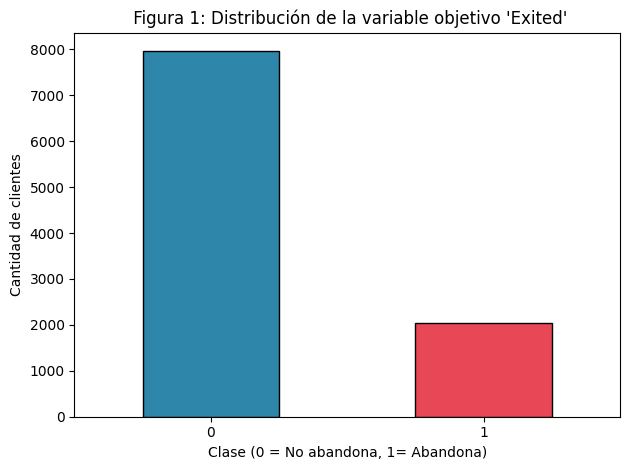

In [11]:
# Conteo absoluto y relativo del 'Target'

print('--' * 40)
print(data['Exited'].value_counts())
print('--' * 40)
print(data['Exited'].value_counts(normalize=True).round(4))
print('--' * 40)

# Ratio de desbalance

mayoritario = data['Exited']. value_counts()[0]
minoritario = data['Exited'].value_counts()[1]
print(f"Ratio de desbalance: {mayoritario/minoritario:.2f}:1")

# Gráfica visual

data['Exited'].value_counts().plot(
    kind= 'bar',
    color= ['#2E86AB','#E84855'],
    edgecolor= 'black'
)

plt.title(" Figura 1: Distribución de la variable objetivo 'Exited'")
plt.xlabel("Clase (0 = No abandona, 1= Abandona)") 
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
> **OBSERVACIONES DURANTE LA EXPLORACIÓN EDA**
 
1. Durante la exploración se identifica 909 valores ausentes (NaN), con tipo de datos float64 en la columna `Tenure`.

2. En la columna `Tenure` se imputa con la mediana los valores ausente para no distorsionar y eliminar datos, la mediana que reemplaza los valores NaN es 5.0. De igual manera se convierte los datos de tipo float64 a int64.

3. Se eliminan 3 columnas irrelevantes: `RowNumber: índice; CustomerId y Surname`, identificadores sin poder predictivo.

4. Se aplicó OHE (One-Hot-Encoding) a las columnas `Geography y Gender` para convertir a variables numéricas.

5. Durante la observación del desbalance en la variable objetivo 'Exited' en la figura 1, se identificó lo siguiente:
```
      clase 0 (No abandona): ~7963 clientes -> parte grande
      clase 1 (Abandona)   : ~2037 clientes -> parte pequeña

      7963/2037 = 3.91 (4)
```
- Por cada 1 cliente que abandona, 4 no lo hacen (No abandona); es decir, en términos prácticos de cada         100 clientes, aprox. 80 no abandonan y solo 20 abandonan.
- El modelo sin corrección tenderá a ignorar la clase minoritaria (Exited=1).
- Es necesario aplicar en el modelo mejorado `class_weight='balanced', SMOTE o undersampling.`


---
# <span style='color: #1B3A6B;'> 5. DIVISIÓN DE DATOS </span>
---
## <span style='color:#2E86AB;'> 5.1 Separar Características (Features) y Objetivo (Target) </span>

In [12]:
# features y targe

target = data['Exited']                                # Variable objetivo X, columna que el modelo debe predecir
features = data.drop(['Exited'], axis =1)              # Variables características Y, eliminando la columna 'Exited'

## <span style='color:#2E86AB;'>5.2 Dividir en Conjunto de Entrenamiento, Validación y Prueba </span>

In [13]:
# Dividir los datos: 60% entrenamiento, 20% validación, 20% prueba

# 1. Dividir dataset en: Entrenamiento temporal 80% y prueba 20%

train_features, test_features, train_target, test_target = train_test_split(
    features,
    target,
    test_size= 0.20, 
    random_state=12345
)


# 2. Dividir Entrenamiento temporal en: Entrenamiento final 60% y validación 20% 

train_features, valid_features, train_target, valid_target = train_test_split(
    train_features,
    train_target,
    test_size = 0.25,
    random_state = 12345
)

---
> **IMPORTANTE**

Los datos se 'DIVIDIERON' en: `train` 60%, `valid` 20% y `test` 20%.


## <span style='color:#2E86AB;'> 5.3 Escalado de Características Numéricas </span> 

In [14]:
# Escalar features numéricas, convirtiendo sus valores para que tengan promedio 0 y desviación estándar 1
# IMPORTANTE: fit() se realiza solo sobre train para evitar data 'leakage'

scaler = StandardScaler()

train_features = scaler.fit_transform(train_features)           # Ajusta el scaler con train y transforma
valid_features = scaler.transform(valid_features)               # Solo transforma, no ajusta
test_features = scaler.transform(test_features)                 # Solo transforma no ajusta

print('--' * 40)
print('                DIMENSIONES DESPUÉS DE DIVIDIR LOS DATOS')
print('--' * 40)
print(f"Train: {train_features.shape}, Valid: {valid_features.shape}, Test: {test_features.shape}")

--------------------------------------------------------------------------------
                DIMENSIONES DESPUÉS DE DIVIDIR LOS DATOS
--------------------------------------------------------------------------------
Train: (6000, 11), Valid: (2000, 11), Test: (2000, 11)


---
# <span style='color:#1B3A6B;'>6. ANÁLISIS DEL EQUILIBRIO DE CLASES </span>
---

## <span style='color:#2E86AB;'> 6.1 Distribución de la Variable Objetivo (Exited) </span>

--------------------------------------------------------------------------------
DISTRIBUCIÓN DE CLASES, CONJUNTO DE ENTRENAMIENTO
--------------------------------------------------------------------------------
Clase 0 (No Abandona): 4781 (79.68%)
Clase 1 (Abandona):    1219 (20.32%)
Ratio de desequilibrio: 3.92:1
--------------------------------------------------------------------------------


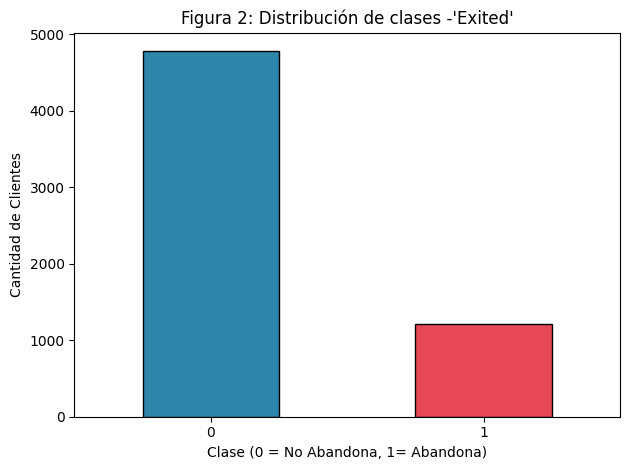

In [15]:
# Visualizar la distribución de clases en el conjunto de entrenamiento

conteo = pd.Series(train_target).value_counts()                  # Cuenta los valores de cada clase
ratio = conteo [0] / conteo[1]                                   # Calcula el ratio de desequilibrio

print('--' * 40)
print('DISTRIBUCIÓN DE CLASES, CONJUNTO DE ENTRENAMIENTO')
print('--' * 40)

print(f"Clase 0 (No Abandona): {conteo[0]} ({conteo[0] / len(train_target):.2%})")
print(f"Clase 1 (Abandona):    {conteo[1]} ({conteo[1] / len(train_target):.2%})")
print(f"Ratio de desequilibrio: {ratio:.2f}:1")
print('--' * 40)

# Gráfica de la distribución

conteo.plot(kind = 'bar',
           color = ['#2E86AB', '#E84855'],
           edgecolor = 'black')
plt.title("Figura 2: Distribución de clases -'Exited'")
plt.xlabel('Clase (0 = No Abandona, 1= Abandona)')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation= 0)
plt.tight_layout()
plt.show()

## <span style='color:#2E86AB;'>6.2 Modelo Base sin Corrección de Desequilibrio </span>

In [16]:
# Entrenar un modelo base sin ningún ajuste de desequilibrio
# Objetivo: Observar el impacto del desequilibrio sobre el F1 Score.

modelo_base = RandomForestClassifier(random_state= 12345, n_estimators =50)
modelo_base.fit(train_features, train_target)

pred_base = modelo_base.predict(valid_features)                       # Predicciones en validación
proba_base = modelo_base.predict_proba (valid_features)[:, 1]          # Probabilidades para AUC-ROC

f1_base = f1_score(valid_target, pred_base)                      # f1 score del modelo base
auc_base = roc_auc_score(valid_target, proba_base)               # AUC_ROC del modelo base

print('--' * 40)
print("         MODELO BASE - SIN CORRECCIÓN DE DESEQUILIBRIO")
print('--' * 40)
print(f"f1 Score (Validación): {f1_base:.4f} ({f1_base:.2%})")
print(f"AUC-ROC  (Validación): {auc_base:.4f} ({auc_base:.2%})")
print(f"Cumple f1 ≥ 0.59?      {'SÍ' if f1_base >= 0.59 else 'NO'}")


print('='*55)
print('REPORTE DE CLASIFICACIÓN — MODELO BASE')
print('='*55)
print(classification_report(
    valid_target,
    pred_base,
    target_names=['No abandona (0)', 'Sí Abandona (1)']
))
print('='*55)

--------------------------------------------------------------------------------
         MODELO BASE - SIN CORRECCIÓN DE DESEQUILIBRIO
--------------------------------------------------------------------------------
f1 Score (Validación): 0.5541 (55.41%)
AUC-ROC  (Validación): 0.8368 (83.68%)
Cumple f1 ≥ 0.59?      NO
REPORTE DE CLASIFICACIÓN — MODELO BASE
                 precision    recall  f1-score   support

No abandona (0)       0.88      0.96      0.92      1609
Sí Abandona (1)       0.73      0.45      0.55       391

       accuracy                           0.86      2000
      macro avg       0.81      0.70      0.74      2000
   weighted avg       0.85      0.86      0.85      2000



---
> **OBSERVACIONES DEL MODELO BASE**

* Para el `modelo base` se eligió **Random Forest** con `n_estimators=50` como línea base para evaluar el impacto del desbalance de clases.

**Resultados obtenidos:**

1. **F1-Score = 55.41%** (por debajo del umbral objetivo ≥ 59%)
2. **AUC-ROC = 83.68%** (buena capacidad de discriminación)

**Análisis de resultados:**

* El **AUC-ROC de 83.68%** indica que el modelo tiene una **buena capacidad para distinguir** entre clientes que abandonan y los que no.

* Sin embargo, el **F1-Score de 55.41%** revela que el modelo tiene **dificultades para predecir correctamente la clase minoritaria** (clientes que abandonan).

* Esta discrepancia entre AUC-ROC alto y F1-Score bajo es **típica en datasets desbalanceados**, donde el modelo aprende principalmente de la clase mayoritaria.

**Impacto del desbalance:**

* El ratio 3.92:1 hace que el modelo se **sesge hacia predecir "No abandona"** (clase 0).

* Esto resulta en **alta precisión general** pero **baja sensibilidad** para detectar clientes que realmente abandonarán.

* **Consecuencia de negocio:** El banco perdería oportunidades de retener clientes en riesgo.

**Reporte de clasificación por clase:**

* La **Precisión de 73%** en clase 1 indica que cuando el modelo predice que un cliente abandonará, acierta 7 de cada 10 veces.

* El **Recall de 45%** en clase 1 es el dato más crítico, el modelo solo detecta 1 de cada 4 clientes que realmente abandonarán, dejando escapar el 55% restante.

* Esta combinación de Precisión aceptable pero Recall bajo en la clase minoritaria es exactamente lo que castiga a F1 Score (55.41%) y justifica aplicar las técnicas de corrección de desequilibrio en la sección 7. 

---
# <span style='color:#1B3A6B;'> 7. MODELO MEJORADO - CORRECCIÓN DEL DESEQUILIBRIO </span>
---

## <span style='color:#2E86AB;'> 7.1 Enfoque 1 - Ajuste de Pesos de Clase (class_weight='balanced')

Para el primer enfoque se utilizará `class_weight= 'balanced'`, con el objetivo de penalizar más los errores sobre la clase minoritaria (Exited=1), sin modificar los datos originales.

In [17]:
# Árbol de Decisión con class_weight= 'balanced'

best_f1_dtc    = 0
best_depth_dtc = 0

# Modelo Árbol de decisión
for depth in range(1,21):
    model_dtc = DecisionTreeClassifier(
        random_state = 12345, 
        max_depth    = depth, 
        class_weight ='balanced')

# Entrenamiento de datos
    model_dtc.fit(train_features,train_target)

# Predicción y validación de datos
    pred_dtc = model_dtc.predict(valid_features)
    f1_dtc   = f1_score(valid_target,pred_dtc)

# Condición para escoger mejor depth y f1 Score    
    if f1_dtc > best_f1_dtc:
        best_f1_dtc    = f1_dtc
        best_depth_dtc = depth 

print('--' * 40)
print("              ÁRBOL DE DECISIÓN - class_weight='balanced'")
print('--' * 40)

print(f"Mejor profundidad= {best_depth_dtc}")
print(f"F1 Score (validación)= {best_f1_dtc:.4f} ({best_f1_dtc:.2%})")
print('--' * 40)

    

--------------------------------------------------------------------------------
              ÁRBOL DE DECISIÓN - class_weight='balanced'
--------------------------------------------------------------------------------
Mejor profundidad= 6
F1 Score (validación)= 0.5587 (55.87%)
--------------------------------------------------------------------------------


In [18]:
# Bosque Aleatorio con class_weight= 'balanced'

best_f1_rfc    = 0
best_n_est_rfc = 0

# Bucle for para encontrar mejor est y aplicar modelo 'Bosque Aleatorio'

for est in range(10, 101, 10):
    model_rfc = RandomForestClassifier(
        random_state = 12345,
        n_estimators = est,
        class_weight = 'balanced'
    )
# Entrenar modelo
    model_rfc.fit(train_features, train_target)

# Encontrar predict y f1_Score

    predict_rfc = model_rfc.predict(valid_features)
    f1_rfc      = f1_score(valid_target, predict_rfc)

    if f1_rfc > best_f1_rfc:
        best_f1_rfc    = f1_rfc
        best_n_est_rfc = est

print('--' * 40)
print("                   BOSQUE ALEATORIO - class_weight = 'balanced'")
print('--' * 40)

print(f"Mejor número de árboles: {best_n_est_rfc}")
print(f"F1 Score (Validación): {best_f1_rfc:.4f} ({best_f1_rfc:.2%})")

--------------------------------------------------------------------------------
                   BOSQUE ALEATORIO - class_weight = 'balanced'
--------------------------------------------------------------------------------
Mejor número de árboles: 90
F1 Score (Validación): 0.5626 (56.26%)


In [19]:
# Regresión Logística con class_weight='balanced'

model_lr = LogisticRegression(random_state= 12345,
                             class_weight= 'balanced',
                             solver= 'liblinear')

# Entrenamiento de features y target de entrenamiento
model_lr.fit(train_features, train_target)

# Predicción y f1_score  
predict_lr = model_lr.predict(valid_features)
f1_lr = f1_score(valid_target, predict_lr)

print('--' * 40)
print("                 REGRESIÓN LOGÍSTICA - class_weight='balanced'")
print('--' * 40)

print(f"f1 Score (Validación): {f1_lr:.4f} ({f1_lr:.2%})")



--------------------------------------------------------------------------------
                 REGRESIÓN LOGÍSTICA - class_weight='balanced'
--------------------------------------------------------------------------------
f1 Score (Validación): 0.4768 (47.68%)


In [20]:
# Comparación de resultados de los tres modelos

modelos = {
    'ÁRBOL DE DECISIÓN'   : best_f1_dtc,
    'BOSQUE ALEATORIO'    : best_f1_rfc,
    'REGRESIÓN LOGÍSTICA' : f1_lr
}

acurracy_umbral = 0.59
modelo_max = max(modelos.items(), key = lambda x: x[1])

print('--' * 40)
print(f"El mejor modelo es: {modelo_max[0]} con {modelo_max[1]:.2%}")
print('--' * 40)

print(f"\n Cumple el umbral de 0.59? {'SÍ' if modelo_max[1] >= acurracy_umbral else 'NO'}")

--------------------------------------------------------------------------------
El mejor modelo es: BOSQUE ALEATORIO con 56.26%
--------------------------------------------------------------------------------

 Cumple el umbral de 0.59? NO


---
> **OBSERVACIONES - ENFOQUE 1 (class_weight = 'balanced')**

El modelo mejor seleccionado en el `Enfoque 1` es **Bosque Aleatorio** con **56.26%** de exactitud.
```
                           MODELO         EXACTITUD
                    - Bosque Aleatorio    : 56.26%
                    - Árbol de Decisión   : 55.87%
                    - Regresión Logística : 47.68%
```

**Cumplimiento del objetivo:**

* La exactitud de validación del 56.26% **NO** supera el umbral establecido del 59%, por lo tanto **NO** cumple con el requisito del proyecto.



## <span style='color:#2E86AB;'> 7.2 Enfoque 2 - RANDOM FOREST OVERSAMPLING con SMOTE </span>

Para el `Enfoque 2` se utilizará `SMOTE` (Synthetic Minority Oversampling Technique) para generar muestras sintéticas (artificiales) de la clase minoritaria en el conjunto de `ENTRENAMIENTO (train)`, generando nuevos datos basándose en los existentes. 

**IMPORTANTE:** SMOTE se aplica SOLO al conjunto de entrenamiento, nunca a validación ni test.

In [21]:
# Aplicando SMOTE al conjunto de train


smote = SMOTE(random_state = 12345)                                   # Crear una instancia del algoritmo SMOTE con semilla fija para reproducibilidad

train_features_smote, train_target_smote = smote.fit_resample(train_features, train_target)    # Devuelve las características balanceadas y las etiquetas balanceadas

print('--' * 40)
print('           DISTRIBUCIÓN DESPUÉS DE APLICAR SMOTE')
print('--' * 40)
 
print(pd.Series(train_target_smote).value_counts())                   #  Convierte el array target a Series de pandas para usar value_counts()
print('--' * 40)

--------------------------------------------------------------------------------
           DISTRIBUCIÓN DESPUÉS DE APLICAR SMOTE
--------------------------------------------------------------------------------
Exited
0    4781
1    4781
Name: count, dtype: int64
--------------------------------------------------------------------------------


In [22]:
# Bosque Aleatorio entrenado con datos SMOTE

best_f1_smote  = 0
best_est_smote = 0
best_dep_smote = 0

for est in range(10, 101, 10):
    for depth in [5, 10, 15, 20, None]:
        model_smote = RandomForestClassifier(random_state = 12345,
                                             n_estimators  = est,
                                             max_depth = depth)
        
        model_smote.fit(train_features_smote, train_target_smote)      # Entrenar con datos balanceados por SMOTE
        
        predict_smote = model_smote.predict(valid_features)
        f1_smote      = f1_score(valid_target, predict_smote)
        
        if f1_smote >= best_f1_smote:
            best_f1_smote  = f1_smote
            best_dep_smote = depth
            best_est_smote = est


print('--' * 40)
print('                     BOSQUE ALEATORIO - SMOTE')
print('--' * 40)

print(f"Mejor número de árboles: {best_est_smote}")
print(f"Mejor profundidad      : {best_dep_smote}")
print(f"F1 Score (Validación): {best_f1_smote:.4f} ({best_f1_smote:.2%})")

print(f"\n Cumple el umbral de 0.59?: {'SÍ' if best_f1_smote >= acurracy_umbral else 'NO'}   ")

--------------------------------------------------------------------------------
                     BOSQUE ALEATORIO - SMOTE
--------------------------------------------------------------------------------
Mejor número de árboles: 70
Mejor profundidad      : 15
F1 Score (Validación): 0.5992 (59.92%)

 Cumple el umbral de 0.59?: SÍ   


> **OBSERVACIONES - ENFOQUE 2 (SMOTE)**

* **Balanceamiento:** SMOTE logró equilibrar las clases creando **4,781 muestras sintéticas** 
  de la clase minoritaria, igualando la distribución sin duplicación simple.

* **Rendimiento:** Se alcanzó un F1-score de **59.92%** con 70 árboles como parámetro óptimo, 
  **superando exitosamente** el umbral requerido de 59%.

* **Conclusión:** La técnica SMOTE demuestra ser superior proporcionando ejemplos sintéticos de mayor calidad que mejoran la capacidad predictiva del modelo para detectar clientes que abandonan.


## <span style='color:#2E86AB;'> 7.3 Enfoque 3 - Submuestreo de la Clase Mayoritaria (Undersampling)

In [23]:
# Aplicar Undersampling para reducir la clase mayoritaria al tamaño de la clase minoritaria

train_data = pd.DataFrame(train_features)
train_data['target'] = train_target.values

clase_0 = train_data[train_data['target'] == 0]    # Clase mayoritaria (No abandona)
clase_1 = train_data[train_data['target'] == 1]    # Clase minoritaria (Abandona)

clase_0_under = resample(clase_0,                  # Submuestrea la clase mayoritaria 
                         replace      = False,
                         n_samples    = len(clase_1),
                         random_state = 12345
                        )

train_under = pd.concat([clase_0_under, clase_1])  # Une ambas clases balanceadas

train_features_under = train_under.drop('target', axis =1).values
train_target_under   = train_under['target'].values

print('--' * 40)
print('       DISTRIBUCIÓN DESPUÉS DE UNDERSAMPLING')
print('--' * 40)
print(pd.Series(train_target_under).value_counts())
print('--' * 40)

# Entrenar Bosque Aleatorio con datos balanceados por Undersampling

model_under = RandomForestClassifier(random_state = 12345,
                                    n_estimators = 50)
model_under.fit(train_features_under, train_target_under)


predict_under = model_under.predict(valid_features)
f1_under      =f1_score(valid_target, predict_under)

print(f"\n F1_score (Validación): {f1_under:.4f} ({f1_under:.2%})")

print(f" Cumple el umbral de 0.59? {'SÍ' if f1_under >= acurracy_umbral else 'NO'}")


--------------------------------------------------------------------------------
       DISTRIBUCIÓN DESPUÉS DE UNDERSAMPLING
--------------------------------------------------------------------------------
0    1219
1    1219
Name: count, dtype: int64
--------------------------------------------------------------------------------

 F1_score (Validación): 0.5449 (54.49%)
 Cumple el umbral de 0.59? NO


---
> **OBSERVACIONES - ENFOQUE 3 (UNDERSAMPLING)**

* **Balanceamiento:** `UNDERSAMPLING` logra equilibrar las clases creando **1,219** muestras sintéticas de las muestras mayoritarias.

* **Rendimiento:** Se alcanzó un F1-score de **54.49%** no mejora el modelo base y es **insuficiente** para cumplir el umbral requerido 59%.

* **Conclusión:** El undersampling aleatorio no proporciona la mejora necesaria para alcanzar el objetivo del proyecto.

---
# <span style='color:#1B3A6B;'> 8. SELECCIÓN DEL MEJOR MODELO </span>
---
## <span style='color:#2E86AB;'> 8.1 Comparación de Resultados en Validación </span>

In [24]:
# Tabla comparativa de todos los modelos y enfoques - ordenado por f1_score

f1_umbral = 0.59

modelos = {
    'Base - Sin corrección'                       : best_f1_base   if 'best_f1_base'   in dir() else f1_base,
    'Árbol Decisión - class_weight'               : best_f1_dtc,
    'Bosque Aleatorio - class_weight'             : best_f1_rfc,
    'Regresión Logística - class_weight'          : f1_lr,
    'Bosque Aleatorio - Oversampling (Smote)'     : best_f1_smote,
    'Bosque Aleatorio - Undersampling'            : f1_under
}

print('--' * 40)
print('                COMPARACIÓN DE MODELOS - F1 SCORE EN VALIDACIÓN')
print('--' * 40)

for nombre, f1 in sorted(modelos.items(), key= lambda x: x[1], reverse=True):
    cumple = '✓ SÍ' if f1 >= f1_umbral else '✗ NO'
    print(f"{cumple} {nombre:<45}: {f1:.4f} ({f1:.2%})")

--------------------------------------------------------------------------------
                COMPARACIÓN DE MODELOS - F1 SCORE EN VALIDACIÓN
--------------------------------------------------------------------------------
✓ SÍ Bosque Aleatorio - Oversampling (Smote)      : 0.5992 (59.92%)
✗ NO Bosque Aleatorio - class_weight              : 0.5626 (56.26%)
✗ NO Árbol Decisión - class_weight                : 0.5587 (55.87%)
✗ NO Base - Sin corrección                        : 0.5541 (55.41%)
✗ NO Bosque Aleatorio - Undersampling             : 0.5449 (54.49%)
✗ NO Regresión Logística - class_weight           : 0.4768 (47.68%)


## <span style='color:#2E86AB;'> 8.2 Modelo Seleccionado y Justificación </span>

El modelo seleccionado es **Bosque Aleatorio - Oversampling (SMOTE)** con **59.92%** de F1 Score en validación.

**1. Cumplimiento del objetivo:**

* El F1 Score de validación de 59.92% supera el umbral mínimo requerido de 59% cumpliendo con el requisito del proyecto.

**2. Superioridad comparativa:**
```
                      MODELO                            F1 SCORE
           Bosque Aleatorio - Oversampling (Smote)      : 59.92%
           Bosque Aleatorio - class_weight              : 56.26%
           Árbol Decisión - class_weight                : 55.87%
           Base - Sin corrección                        : 55.41%
           Bosque Aleatorio - Undersampling             : 54.49%
           Regresión Logística - class_weight           : 47.68%
```

**3. Ventajas técnicas del modelo:**

El Bosque Aleatorio Oversampling con `Smote` combina dos fortalezas complementarias:

* **Bosque Aleatorio:** al entrenar múltiples árboles de decisión en paralelo y promediar sus resultados, reduce el overfitting (sobreajuste) y es más robusto que un solo árbol, lo que explica por qué superó al Bosque Aleatorio con class_weight (56.26%) y a la regresión logística (47.68%).

* **Oversampling (Smote):** Al crear nuevas observaciones sintéticas interpolando entre vecinos de la clase minoritaria (clientes que sí abandonan), el modelo aprende con igual peso ambas clases, lo que se tradujo en un F1 Score de 59.92%. A diferencia del Undersampling (54.49%), `SMOTE` **preserva toda la información original** de la clase mayoritaria en lugar de descartarla, lo que explica su mejor rendimiento con respecto a Undersampling se pierde 3,562 registros reales de entrenamiento, mientras que SMOTE los conserva todos y agrega información sintética adicional.

* **Hiperparámetros óptimos:** con n_estimators = 70 y max_depth=15 el modelo logra el mejor equilibrio entre complejidad y capacidad de generalización sobre el conjunto de validación.

## <span style='color:#2E86AB;'>8.3. Búsqueda Sistemática de Hiperparámetros (GridSearchCV) </span>

Se utiliza `GridSearchCV` para explorar de forma exhaustiva y automática múltiples combinaciones de hiperparámetros, usando `scoring='f1'` como criterio de optimización.

In [25]:
# Búsqueda de hiperparámetros del mejor modelo con GridSearchCV

param_grid = {
    'n_estimators'  :  [50, 100, 150, 200],            # Número de árboles a evaluar
    'max_depth'     :  [5, 10, 15, 20, None]           # Profundidad máxima a evaluar 
}

gried_search = GridSearchCV(
    RandomForestClassifier(random_state = 12345,
                          class_weight  = 'balanced'), # Modelo base a optimizar
    param_grid,                                        # Combinaciones de parámetros a probar
    cv      = 5,                                       # Divide los datos en 5 partes para validación cruzada
    scoring = 'f1',                                    # Métrica principal del proyecto
    n_jobs  = -1                                       # Usa todos los núcleos del procesador para acelerar 
)

gried_search.fit(train_features, train_target)         # Entrena todas las combinaciones posibles


print('--' * 40)
print('     RESULTADO GRIDSEARCHCV')
print('--' * 40)

print(f" Los mejores parámetros: {gried_search.best_params_}")
print(f" El mejor F1 Score:      {gried_search.best_score_:.4f} ({gried_search.best_score_:.2%})")

print(f"\n Cumple el Umbral 0.59 ? {'SI' if gried_search.best_score_ >= f1_umbral else 'NO'}")

--------------------------------------------------------------------------------
     RESULTADO GRIDSEARCHCV
--------------------------------------------------------------------------------
 Los mejores parámetros: {'max_depth': 10, 'n_estimators': 150}
 El mejor F1 Score:      0.6174 (61.74%)

 Cumple el Umbral 0.59 ? SI


---
> **OBSERVACIONES**

`GriedSearchCV` encontró que la mejor combinación es **n_estimators = 150 y max_depth = 10** con `F1 Score` (acurracy/exactitud) de **61.74%**, superando el límite establecido de umbral 59%.   

---
# <span style='color:#1B3A6B;'> 9. PRUEBA FINAL DEL MODELO </span>
---

## <span style='color:#2E86AB;'> 9.1 Evaluación con el Conjunto de Prueba </span>

In [26]:
# Entrenar el modelo final con los mejores hiperparámetros encontrados

modelo_final = RandomForestClassifier(
    random_state = 12345,
    n_estimators  = 150,
    max_depth     = 10)

modelo_final.fit(train_features_smote, train_target_smote)       # Entrenar con datos balanceados por SMOTE 

test_predict = modelo_final.predict(test_features)               # Predicciones en TEST
test_proba   = modelo_final.predict_proba(test_features)[:, 1]   # Probabilidades para AUC-ROC

## <span style='color:#2E86AB;'> 9.2. Verificación del umbral de F1 (F1 ≥ 0.59) </span>

In [27]:
# Verificar si el modelo supera el umbral mínimo de F1 = 0.59

f1_test  = f1_score(test_target, test_predict)

auc_test = roc_auc_score(test_target, test_proba)

print('--' * 40)
print('      RESULTADO FINAL CONJUNTO DE PRUEBA')
print('--' * 40)

print(f' F1 Score (Prueba): {f1_test:.4f} ({f1_test:.2%})')
print(f" AUC-ROC (Prueba): {auc_test:.4f} ({auc_test:.2%})")
print(f"\n Cumple con el umbral 0.59? {'SÍ' if f1_test > f1_umbral else 'NO'}")

--------------------------------------------------------------------------------
      RESULTADO FINAL CONJUNTO DE PRUEBA
--------------------------------------------------------------------------------
 F1 Score (Prueba): 0.6441 (64.41%)
 AUC-ROC (Prueba): 0.8618 (86.18%)

 Cumple con el umbral 0.59? SÍ


## <span style='color: #2E86AB;'> 9.3. Distribución Real vs Predicha </span>

In [28]:
# Observar la distribución de predicciones del modelo final vs la distribución real

print('--' * 40)
print("           Distribución real (test):")
print(test_target.value_counts())
print('--' * 40)

print('\n       Distribución predicha (test):')
print(pd.Series(test_predict).value_counts())

--------------------------------------------------------------------------------
           Distribución real (test):
Exited
0    1573
1     427
Name: count, dtype: int64
--------------------------------------------------------------------------------

       Distribución predicha (test):
0    1511
1     489
Name: count, dtype: int64


---
> **OBSERVACIONES**

**Análisis de distribuciones (Real vs Predicha):**

* **Distribución real:** 1,573 no abandonan | 427 sí abandonan
* **Distribución predicha:** 1,511 no abandonan | 489 sí abandonan

**Interpretación del comportamiento del modelo:**

* El modelo predice **más abandonos** (489) de los que realmente ocurren (427), 
  indicando que es **conservador** al identificar clientes en riesgo.

* Esta tendencia es **positiva para el negocio** porque es preferible contactar 
  algunos clientes adicionales (falsos positivos) que perder clientes reales 
  por no detectarlos (falsos negativos).

* El F1-Score de **64.41%** confirma un buen equilibrio entre precisión y 
  recall para detectar clientes que abandonan. 

## <span style='color:#2E86AB;'> 9.4. Métricas Adicionales y Reporte de Clasificación </span>

El F1 Score equilibra Precision y Recall, siendo la métrica principal. El AUC-ROC midel la capacidad del modelo para distingue ente clases, siendo útil para comparar.

In [29]:
print('--' * 40)
print('                  MÉTRICAS ADICIONALES DEL MODELO FINAL')
print('--' * 40)

print(classification_report(
    test_target,
    test_predict,
    target_names= ['No abandona (0)', 'Si Abandona (1)']
))

print('--' * 40)
print(f"F1 Score:  {f1_test:.4f} ({f1_test:.2%})")
print(f"AUC-ROC:   {auc_test:.4f} ({auc_test:.2%})")

--------------------------------------------------------------------------------
                  MÉTRICAS ADICIONALES DEL MODELO FINAL
--------------------------------------------------------------------------------
                 precision    recall  f1-score   support

No abandona (0)       0.91      0.88      0.89      1573
Si Abandona (1)       0.60      0.69      0.64       427

       accuracy                           0.84      2000
      macro avg       0.76      0.78      0.77      2000
   weighted avg       0.85      0.84      0.84      2000

--------------------------------------------------------------------------------
F1 Score:  0.6441 (64.41%)
AUC-ROC:   0.8618 (86.18%)


---
> **OBSERVACIONES**

**Precisión:**

* No abandona (0): 0.91 → de cada 100 que predijo como 'No abandona', 91 realmente no abandonaron.

* Si abandona (1): 0.60 → de cada 100 que predijo como 'Si abandona', 60 realmente si abandonaron.


**Recall:**

* No abandona (0): 0.88 → de 1,573 clientes reales que no abandonan, detectó el 88% (muy bien).

* Si abandona (1): 0.69 → de 427 clientes reales que si abandonaron, detectó el 69% (bueno) 

**F1-Score:**

* No abandona (0): 0.89 → rendimiento de la clase mayoritaria (muy bien rendimiento).

* Si abandona (1): 0.64 → rendimiento de la clase minoritaria (rendimiento moderado, la más importante).

## <span style='color:#2E86AB;'> 9.5. Curva ROC y Comparativa F1 vs AUC-ROC </span>

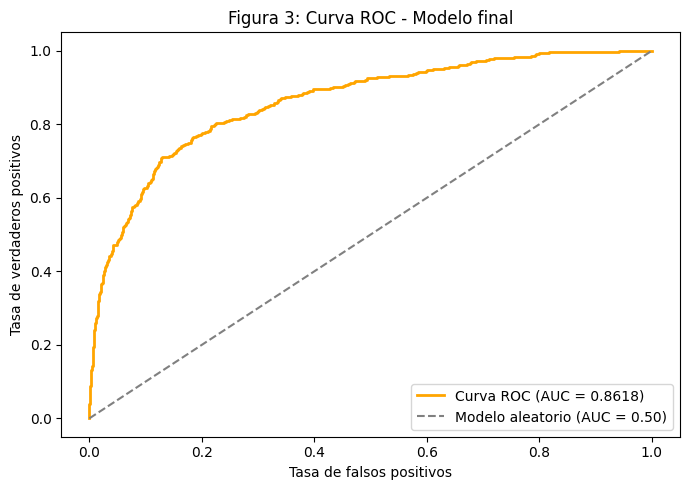

--------------------------------------------------------------------------------
                    COMPARATIVA F1 SCORE vs AUC-ROC
--------------------------------------------------------------------------------
F1 Score:   0.6441 (64.41%)   ← métrica principal
AUC - ROC:  0.8618 (86.18%) ← métrica secundaria


In [30]:
# Gráfica de la curva ROC del modelo final

fpr, tpr, _ = roc_curve(test_target, test_proba)      # Tasa de falsos positivos y verdaderos positivos

plt.figure(figsize= (7, 5))
plt.plot(fpr,
         tpr,
         color = 'orange',
         lw    = 2,
         label = f'Curva ROC (AUC = {auc_test:.4f})')

plt.plot([0, 1],
         [0, 1],
         color     = 'gray',
         linestyle = '--',
         label     = 'Modelo aleatorio (AUC = 0.50)')

plt.title('Figura 3: Curva ROC - Modelo final')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.legend(loc = 'lower right')
plt.tight_layout()
plt.show()

print('--' * 40)
print('                    COMPARATIVA F1 SCORE vs AUC-ROC')
print('--' * 40)

print(f"F1 Score:   {f1_test:.4f} ({f1_test:.2%})   ← métrica principal")
print(f"AUC - ROC:  {auc_test:.4f} ({auc_test:.2%}) ← métrica secundaria")

---
> **OBSERVACIONES**

* En la figura 3, la línea curva azul representa el rendimiento del modelo 
  **Bosque Aleatorio con Smote** en el conjunto de prueba.

* La curva ROC muestra un **excelente rendimiento** (AUC = 86.18%) ya que se 
  acerca significativamente a la esquina superior izquierda, indicando alta 
  capacidad para distinguir entre clientes que abandonan y los que no.

* **Interpretación técnica:** 

  - La curva está muy por encima de la línea diagonal gris (modelo aleatorio).
  - Esto confirma que el modelo tiene una capacidad discriminativa superior 
    al azar para identificar clientes en riesgo de abandono.
  - El AUC de 86.18% clasifica como "muy bueno" en la escala estándar de 
    evaluación de modelos.

## <span style='color: #2E86AB; '> 9.6. Matriz de Confusión </span>

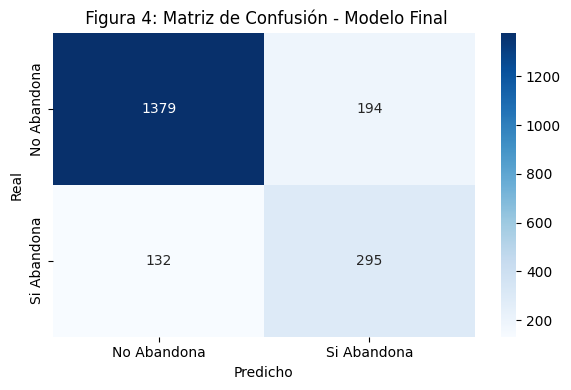

In [31]:
# Matriz de confusión del modelo final

conf_matriz = confusion_matrix(test_target, test_predict)

plt.figure(figsize= (6, 4))
sns.heatmap(conf_matriz,
            annot       = True,
            fmt         = 'd',
            cmap        = 'Blues',
            xticklabels = ['No Abandona', 'Si Abandona'],
            yticklabels = ['No Abandona', 'Si Abandona'])

plt.title(' Figura 4: Matriz de Confusión - Modelo Final')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

---
> **OBSERVACIONES - Matriz de Confusión**

```
                             Predicho
                       No Abandona    Si Abandona
  Real  No Abandona   [ ✅ TN           ❌ FP   ]   ← clientes No Abandona
        Si Abandona   [ ❌ FN           ✅ TP   ]   ← clientes Si Abandona
-----------------------------------------------------------------
                                  Predicho
                         No Abandona    Si Abandona   TOTAL REAL
  Real  No Abandona (0) [  1,379             194      ]  =  1,573 ✅
        Si Abandona (1) [    132             295      ]  =    427 ✅
                         ──────────────────────────────────
          TOTAL PRED       1,511             489         =  2000  total
-----------------------------------------------------------------
```

**Interpretación de resultados:**

- **Verdaderos Negativos (TN = 1,379):** Clientes que NO abandonan y el modelo predice correctamente que NO abandonarán ✅

- **Falsos Positivos (FP = 194):** Clientes que NO abandonan pero el modelo predice incorrectamente que SÍ abandonarán ❌ (genera alertas innecesarias al banco).

- **Falsos Negativos (FN = 132):** Clientes que SÍ abandonan pero el modelo predice incorrectamente que NO abandonarán ❌ ← **el error más costoso para Beta Bank** 

- **Verdaderos Positivos (TP = 295):** Clientes que SÍ abandonan y el modelo predice correctamente que SÍ abandonarán ✅

**Impacto en el negocio:**

El error más crítico para Beta Bank son los **132 Falsos Negativos**: clientes 
que realmente abandonarán pero el modelo no los detecta, perdiendo la 
oportunidad de implementar estrategias de retención. 

**Análisis de eficiencia:**
- **Recall = 69%** (295/427): El modelo detecta 7 de cada 10 clientes que abandonan
- **Precisión = 60%** (295/489): 6 de cada 10 predicciones de abandono son correctas

## <span style='color:#2E86AB;'> 9.7. Importancia de Variables </span>

--------------------------------------------------------------------------------
                        IMPORTANCIA DE VARIABLES
--------------------------------------------------------------------------------
Age                           : 0.3199 (31.99%)
NumOfProducts                 : 0.2484 (24.84%)
Balance                       : 0.1010 (10.10%)
IsActiveMember                : 0.0700 (7.00%)
Tenure                        : 0.0630 (6.30%)
EstimatedSalary               : 0.0547 (5.47%)
CreditScore                   : 0.0489 (4.89%)
Geography_Germany             : 0.0465 (4.65%)
Gender_Male                   : 0.0289 (2.89%)
HasCrCard                     : 0.0098 (0.98%)
Geography_Spain               : 0.0088 (0.88%)
--------------------------------------------------------------------------------


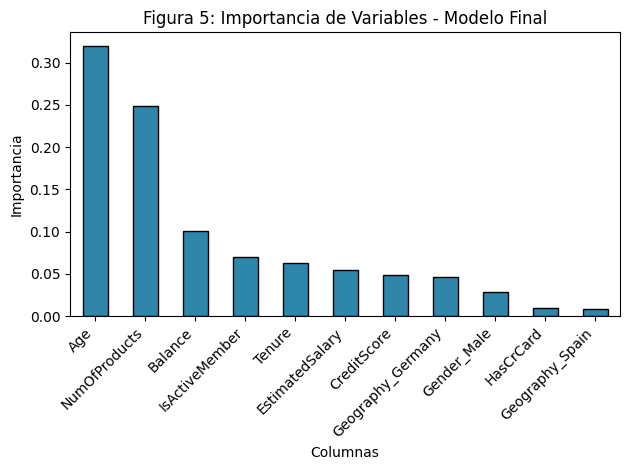

In [32]:
# Importancia de variables del modelo final

important = pd.Series(                                           # Crea una Serie de pandas con las importancias
    modelo_final.feature_importances_,                           # Extrae el peso de cada variable del modelo entrenado
    index = data.drop('Exited', axis = 1).columns                # Asigna el nombre de cada columna como índice
).sort_values(ascending = False)                                 # Ordena de mayor a menor importancia

print('--' * 40)
print('                        IMPORTANCIA DE VARIABLES')
print('--' * 40)

for variable, valor in important.items():                        # Itera sobre cada variable y su valor de importancia
    print(f"{variable:<30}: {valor:.4f} ({valor:.2%})")          # Imprime nombre alineado, valor decimal y porcentaje

print('--' * 40)

important.plot(kind ='bar',
               color ='#2E86AB',
               edgecolor='black')

plt.title('Figura 5: Importancia de Variables - Modelo Final')
plt.ylabel('Importancia')
plt.xlabel('Columnas')
plt.xticks(rotation = 45, ha= 'right')
plt.tight_layout()
plt.show()


---
> **OBSERVACIONES DE VARIABLES**
```
                         Variables           Importancia           
                       Age                    → ~32%   ← LA MÁS DETERMINANTE
                       NumOfProducts          → ~25%
                       Balance                → ~10%
                       IsActiveMember         → ~07%
                       Tenure                 → ~06%
                       EstimatedSalary        → ~06%
                       CreditScore            → ~05%
                       Geography_Germany      → ~05%
                       Gender_Male            → ~03%
                       HasCrCard              → ~01%
                       Geography_Spain        → ~01%
                       
```

**Análisis por variable**

* ``Age (32%)`` es por lejos la variables más importante. Los clientes de mayor edad tienen mayor tendencia a abandonar el banco; posiblemente factores como cambios en la necesidad financiera que buscan los clientes o productos acordes a su edad.

* `NumOfProducts (25%) ` se encuentra en segundo lugar. Los clientes que tienen 1 producto tienen poca fidelidad y los que tienen 3 o más pueden sentirse sobrecargado de productos; por lo tanto clientes que tienen poco o demasiados productos tienen mayor riesgo de abandono.

* `Balance (10%)` el saldo bancario de clientes ya sea alto o bajo influye como tercer lugar en el comportamiento de abandono de clientes.

*  `IsActiveMembe (7%)` tiene sentido que clientes no activos tengan mayor probabilidad de abandonar.

* `Tenure (6%) y EstimatedSalary (6%)` aportan información sobre el perfil económico del cliente, razonable a clientes que no tienen una constancia en número de depósitos en las cuentas personales.

* `CreditScore (5%), Geography_Germany (5%)` de igual manera aportan información de perfil económico del cliente, también sugiere que clientes de Alemania (factor geográfico relevante) tienen un comportamiento de abandono diferente a los de España y Francia.

* `Gender_Male, HasCrCard, Geography_Spain` tienen un impacto mínimo (menos del 4%), por lo tanto son factores no determinantes para predecir el abandono.

**Conclusión del Análisis**

Enfocar estrategias de retención principalmente en clientes de **mayor edad**, con **pocos productos contratados** y que estén **inactivos**, ya que estas tres variables concentran más del 64% del poder predictivo.

---
# <span style='color:#1B3A6B;'> 10. CONCLUSIONES </span>
---

**1.** De los modelos entrenados, el modelo elegido es el `Bosque Aleatorio - Oversampling (SMOTE)` con un F1 Score de validación de `59.92%`, superando al resto de los modelos evaluados.

**2.** El desequilibrio de clases impactó significativamente al modelo base, que obtuvo un F1 Score de `55.41%` sin corrección. Tras aplicar `SMOTE`, el F1 Score mejoró a `59.92%`.

**3.** Con la selección del mejor modelo, se realizó una búsqueda sistemática de hiperparámetros con `GridSearchCV`, encontrando la mejor combinación `n_estimators= 150 ,max_depth= 10`.

**4.** El modelo final obtuvo un F1 Score de `64.41%` en el conjunto de prueba, superando el umbral mínimo requerido de 59%.

**5.** Comparativa entre las métricas principales:
```
- F1 Score : 64.41%  ← métrica principal (equilibrio Precision-Recall)
- AUC-ROC  : 86.18%  ← métrica secundaria (capacidad discriminatoria general)
```
**6.** Las variables más importantes para predecir el abandono fueron:

* `[Age             ]` → [~32%]  ← **la más determinante**
* `[NumOfProducts   ]` → [~25%]
* `[Balance         ]` → [~10%]
* `[IsActiveMember  ]` → [~07%]
* `[Tenure          ]` → [~06%]
* `[EstimatedSalary ]` → [~06%]

* Estas 6 variables concentran el 86% del poder predictivo del modelo.
---
## <span style='color:#2E86AB;'> RECOMENDACIONES A BETA BANK </span>
---

**1. Implementar el modelo:** Con `64.41%` de F1 Score el modelo esta listo para identificar clientes en riesgo de abandono y permitir acciones de prevención.

**2. Gestionar Falsos Negativos (132 clientes):** Estos representan clientes que realmente abandonarán pero el modelo no detecta. Considerar ajustar el umbral de decisión para capturar más casos en riesgo.

**3. Enfocarse en variables clave:** Las variables con mayor peso predictivo deben ser mayormente monitoreadas y actualizadas para detectar señales temprana de abandono.

**4. Reevaluar el modelo periódicamente:** Reentrenar el modelo cada 6 meses con datos actualizados, debido a los cambios de comportamiento en los clientes con el tiempo.

**5. Ampliar el dataset:** Con mayor cantidad de datos históricos principalmente de clientes que abandonaron, equilibrando así los dos grupos (No abandonan=0 y Si abandonan=1) para que el modelo mejore la capacidad de detección y reducir los `Falsos Negativos`.